#  Prétraitement des Données

Tests et visualisation des étapes de prétraitement : nettoyage, normalisation, création de masques, découpage en patchs, augmentation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys,os
# Ajouter src au chemin de recherche des modules
notebook_dir = os.getcwd()
src_path = os.path.abspath(os.path.join(notebook_dir, '..', 'src'))
if src_path not in sys.path:
	sys.path.append(src_path)
import image_search,pretraitement_cnn
from tqdm import tqdm # barre de progression
from multiprocessing.dummy import Pool as ThreadPool

from numpy import ceil
from PIL import Image



# Preprocessing for Model from scratch 

Nous allons redimentionner tous les images dans le format 256x256 .
De base les images sont pris dans des contextes trés varié, pour certains images,le chient ne represente qu'une toute petite portion,aussi nous avons decider d'utuliser les bounding-box pour recadrer les images puis completer par un padding afin d'obtenir une imagede taille 255x255

## A quoi ressemble nos images avant et aprés ?

In [4]:
df_imgs=image_search.index_dataset(r"..\data\images",)

In [3]:
df_imgs['class'].values

array(['n02085620-Chihuahua', 'n02085620-Chihuahua',
       'n02085620-Chihuahua', ..., 'n02116738-African_hunting_dog',
       'n02116738-African_hunting_dog', 'n02116738-African_hunting_dog'],
      dtype=object)

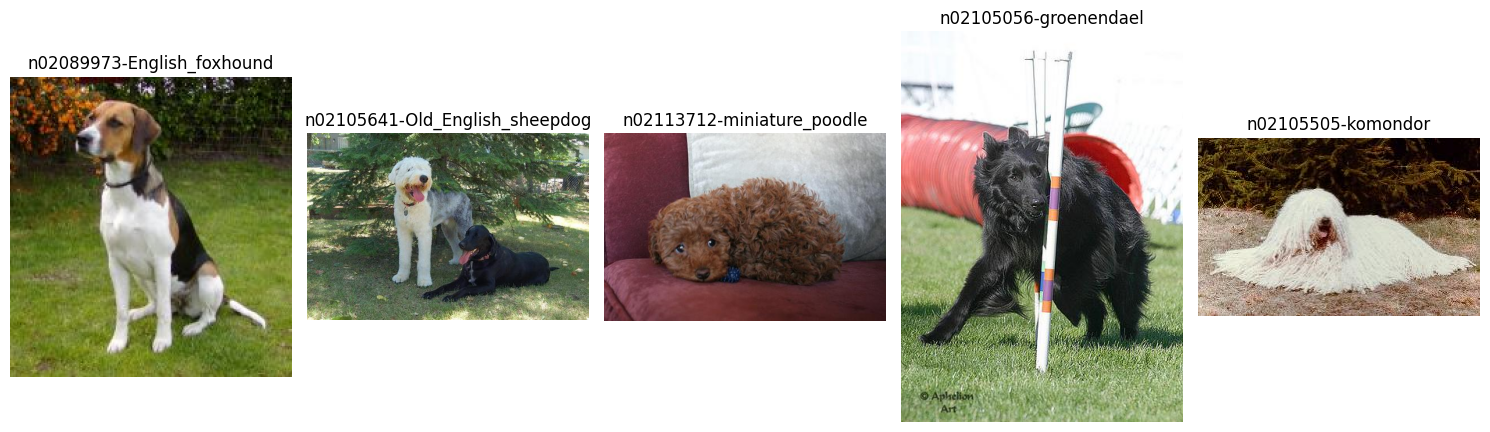

In [9]:
sample=df_imgs.sample(n=6)
image_search.show_images(sample)

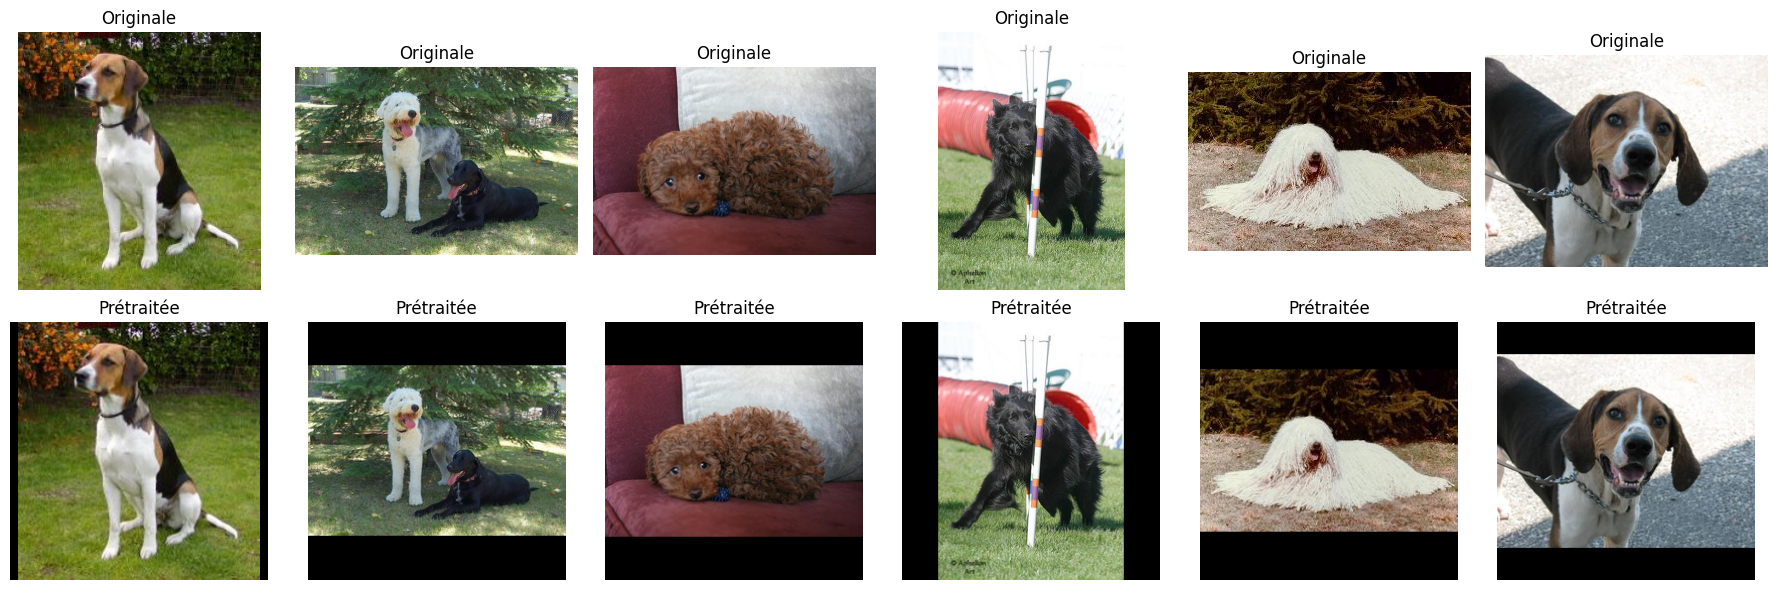

In [12]:
n_images = len(sample)
fig, axs = plt.subplots(2, n_images, figsize=(3*n_images, 6))

for i, (_, row) in enumerate(sample.iterrows()):
    img = Image.open(row['image_path'])
    axs[0, i].imshow(img)
    axs[0, i].set_title("Originale")
    axs[0, i].axis('off')
    
    img_prep = pretraitement_cnn.resize_with_padding(
        img,
   
    )
    axs[1, i].imshow(img_prep)
    axs[1, i].set_title("Prétraitée")
    axs[1, i].axis('off')

plt.tight_layout()
plt.show()

Si on choisit certains exemples d'images ou le chien occupe une taille faible alors on note que un fort gain suite au prétraitement.

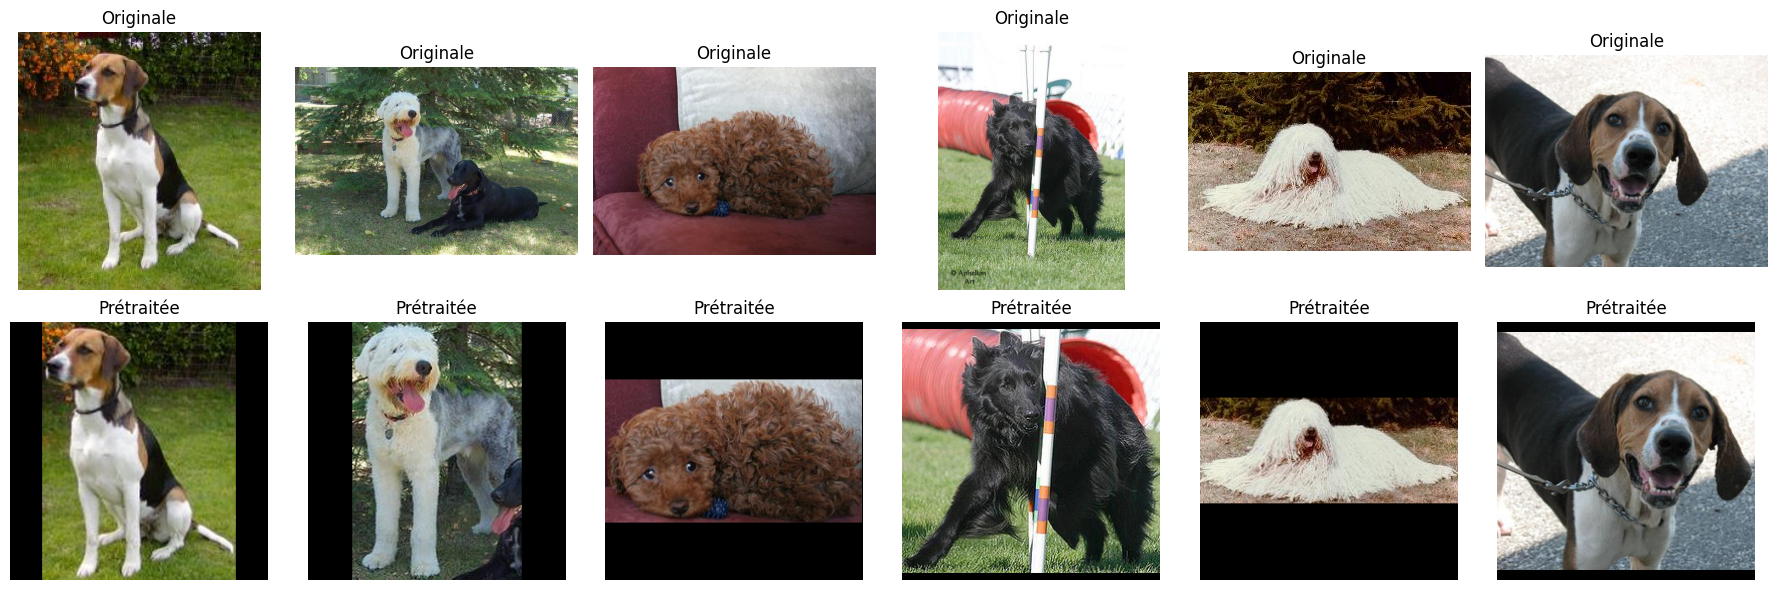

In [11]:
fig, axs = plt.subplots(2, n_images, figsize=(3*n_images, 6))

for i, (_, row) in enumerate(sample.iterrows()):
    img = Image.open(row['image_path'])
    axs[0, i].imshow(img)
    axs[0, i].set_title("Originale")
    axs[0, i].axis('off')
    
    img_prep = pretraitement_cnn.recadrer_selon_bbox(
        img,
        img_path=row['image_path'],
        annotation_dir="../data/annotation" 
    )
    axs[1, i].imshow(img_prep)
    axs[1, i].set_title("Prétraitée")
    axs[1, i].axis('off')

plt.tight_layout()
plt.show()

Nous avons bien des images 256x256 avec un focus sur le chien.
Le padding n'est peut-etre pas une bonne idée, on ne le saura qu'aprés avoir entrainé le modele,au mieux on peut faire des rotations et des zomes et esperer corriger ce biais.Sinon,une autre solution serais d'etirer les images afin d'occuper toute l'espace.

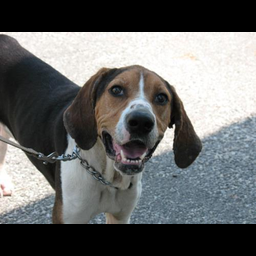

In [13]:
img_prep.size 
img_prep

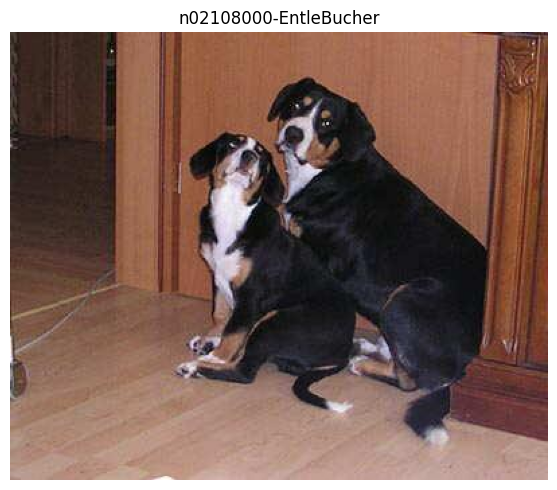

In [ ]:
image_search.show_images(sample.iloc[[4]])

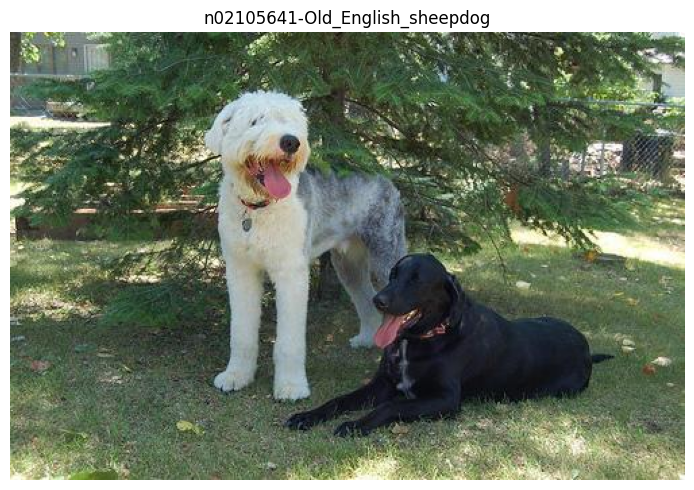

In [14]:
image_search.show_images(image_search.search_by_keyword(df_imgs,"n02105641_8273"))

Cette image, n02105641_8273, nous montre que dans une image plusieurs chiens de races differents peuvent cohabiter, ainsi sans les bunding-box il nous serais impossible de faire un modele qui predise correctement la race des chiens.
Voyons que le un pretraitement ferais à cette image

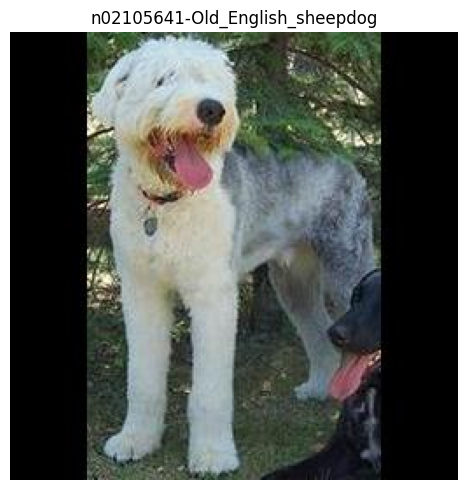

In [20]:
# n02105641_8273 aprés prétraitement

row = image_search.search_by_keyword(df_imgs,"n02105641_8273").iloc[0] 
img_path = row['image_path']
img = Image.open(img_path)

img_prep = pretraitement_cnn.recadrer_selon_bbox(
    img,
    img_path=img_path,
    annotation_dir="../data/annotation"
)

output_dir = "../data/teste_transf"
rel_path = os.path.relpath(img_path, "../data/images")
save_path = os.path.join(output_dir, rel_path)
os.makedirs(os.path.dirname(save_path), exist_ok=True)
img_prep.save(save_path)

# Afficher l'image prétraitée sauvegardée dans ../data/teste_transf

df_test = pd.DataFrame([{
	"image_path":save_path,
	"class": row["class"],
	"filename": row["filename"]
}])

image_search.show_images(df_test)

L'autre chien apparait legerement mais bon c'est mieux que precedement

> une image avec plusieurs chiens, a-ton plusieurs boites ?

a priori non,mais  si cela s'avere le cas tel que nous avons ecrit notre fonction `recadrer_selon_bbox`elle ne conservera que le premier chien . Comme ce processus sera appliqué à tous les images (train comme test),le modele ne verra jamais plusieurs chiens, tous se passera bien car apres tout une image, meme si elle montre plusieurs chiens ce sera nécessairement de la même race.

## Generation d'un nouveau dataset prétraité

In [5]:
# teste avec un seul image

row = df_imgs.sample(n=1).iloc[0] # Sélection d'une image au hasard
img_path = row['image_path']
img = Image.open(img_path)

img_prep = pretraitement_cnn.recadrer_selon_bbox(
    img,
    img_path=img_path,
    annotation_dir="../data/annotation"
)

output_dir = "../data/teste_transf"
rel_path = os.path.relpath(img_path, "../data/images")
save_path = os.path.join(output_dir, rel_path)
os.makedirs(os.path.dirname(save_path), exist_ok=True)
img_prep.save(save_path)

Traiter chaque image une par une est extremement lent avec une boucle for, nous allons paraller le processus 

In [6]:

def traiter_img(row):
    img_path = row['image_path']
    img = Image.open(img_path)
    img_prep = pretraitement_cnn.recadrer_selon_bbox(
        img,
        img_path=img_path,
        annotation_dir="../data/annotation"
    )
    rel_path = os.path.relpath(img_path, "../data/images")
    save_path = os.path.join(output_dir, rel_path)
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    img_prep.save(save_path)


Le parallélisme ici permet de traiter plusieurs images en même temps plutôt qu'une par une. Concrètement, chaque thread :

- charge une image depuis le disque,
- la recadre à l’aide de ses annotations
- et la sauvegarde dans un nouveau répertoire.

Au lieu de faire cela image après image, on le fait en parallèle sur plusieurs images à la fois, grâce à ThreadPool. Cela permet d’exploiter les cœurs du processeur pour accélérer fortement les opérations qui prennent du temps, comme l’ouverture et la sauvegarde de fichiers.

In [7]:

output_dir = "../data/images_transf_256x256"

# dataframe to list dict
rows = df_imgs.to_dict(orient='records')

def traiter_img_safe(row):
    """
    Wrapper de traitement capturant les exceptions et permettant
    l'utilisation avec ThreadPool + tqdm.
    """
    try:
        traiter_img(row)
    except Exception as e:
        print(f"Erreur sur {row['image_path']}: {e}")
    return 1  # on retourne 1 pour incrémenter la barre

# Nombre de threads = nombre de cœurs
n_threads = os.cpu_count()

# Lancement du pool de threads et mise à jour de tqdm
with ThreadPool(n_threads) as pool:
    for _ in tqdm(pool.imap_unordered(traiter_img_safe, rows),
                  total=len(rows),
                  desc="Progression totale"):
        pass


Progression totale: 100%|██████████| 20580/20580 [53:00<00:00,  6.47it/s]


53 munites pour effectuer tout le processus avec multi-threading